<h1> Cargar Los Datos </h1>

In [9]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns

marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

<h1> Limpieza y validación de datos </h1>

In [10]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

print(marketing.isna().sum())
print(new_users.isna().sum())
print(events.isna().sum())
print(participants.isna().sum())

# duplicados
print(marketing.duplicated().sum())
print(new_users.duplicated().sum())
print(events.duplicated().sum())
print(participants.duplicated().sum())

name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64
user_id       0
first_date    0
region        0
device        0
dtype: int64
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64
user_id    0
group      0
ab_test    0
dtype: int64
0
0
0
0


<h1> Unir datasets </h1>

In [11]:
data = participants.merge(new_users, on='user_id', how='left')
data = data.merge(events, on='user_id', how='left')

<h1> Validación de la prueba A/B </h1>

In [12]:
users_in_both = participants.groupby('user_id')['group'].nunique()
users_in_both = users_in_both[users_in_both > 1]
print(len(users_in_both))

data = data[data['ab_test'] == 'recommender_system_test']
data = data[data['region'] == 'EU']

data['event_dt'] = pd.to_datetime(data['event_dt'])
data['first_date'] = pd.to_datetime(data['first_date'])

data = data[
    (data['event_dt'] - data['first_date']).dt.days <= 14
]

print(f"Usuarios antes de limpiar duplicados: {data['user_id'].nunique()}")

# Eliminar usuarios que están en ambos grupos
users_to_remove = users_in_both.index
data_clean = data[~data['user_id'].isin(users_to_remove)]

print(f"Usuarios después de limpiar duplicados: {data_clean['user_id'].nunique()}")
print(f"Usuarios eliminados: {len(users_to_remove)}")

441
Usuarios antes de limpiar duplicados: 3481
Usuarios después de limpiar duplicados: 3040
Usuarios eliminados: 441


<h1> Análisis del embudo </h1>

In [13]:
print("=== ANÁLISIS DEL EMBUDO CORREGIDO ===")

# Identificar usuarios que completaron cada paso
users_login = set(data_clean[data_clean['event_name'] == 'login']['user_id'])
users_page = set(data_clean[data_clean['event_name'] == 'product_page']['user_id'])
users_cart = set(data_clean[data_clean['event_name'] == 'product_cart']['user_id'])
users_purchase = set(data_clean[data_clean['event_name'] == 'purchase']['user_id'])

# Crear embudo lógico: solo usuarios que siguieron el orden correcto
users_page_valid = users_page & users_login
users_cart_valid = users_cart & users_page_valid
users_purchase_valid = users_purchase & users_cart_valid

# Crear tabla del embudo corregida
funnel_corrected = pd.DataFrame(index=['A', 'B'])

for group in ['A', 'B']:
    group_users = set(data_clean[data_clean['group'] == group]['user_id'])
    
    funnel_corrected.loc[group, 'login'] = len(users_login & group_users)
    funnel_corrected.loc[group, 'product_page'] = len(users_page_valid & group_users)
    funnel_corrected.loc[group, 'product_cart'] = len(users_cart_valid & group_users)
    funnel_corrected.loc[group, 'purchase'] = len(users_purchase_valid & group_users)

print("Embudo corregido:")
print(funnel_corrected)

# Calcular conversiones
funnel_corrected['conversion_page_to_cart'] = funnel_corrected['product_cart'] / funnel_corrected['product_page']
funnel_corrected['conversion_cart_to_purchase'] = funnel_corrected['purchase'] / funnel_corrected['product_cart']

print("\nCon conversiones:")
print(funnel_corrected)

=== ANÁLISIS DEL EMBUDO CORREGIDO ===
Embudo corregido:
    login  product_page  product_cart  purchase
A  2279.0        1476.0         448.0     153.0
B   760.0         431.0         116.0      43.0

Con conversiones:
    login  product_page  product_cart  purchase  conversion_page_to_cart  \
A  2279.0        1476.0         448.0     153.0                 0.303523   
B   760.0         431.0         116.0      43.0                 0.269142   

   conversion_cart_to_purchase  
A                     0.341518  
B                     0.370690  


<h1> Distribución temporal </h1>

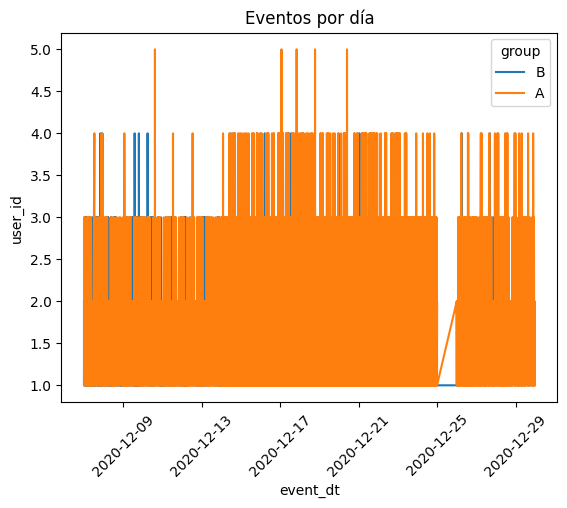

In [6]:
daily_events = data.groupby(['event_dt', 'group'])['user_id'].count().reset_index()

sns.lineplot(data=daily_events, x='event_dt', y='user_id', hue='group')
plt.xticks(rotation=45)
plt.title('Eventos por día')
plt.show()

<h1> Evaluacion De Estadistica </h1>

In [14]:
import numpy as np
from scipy import stats as st

# 1. Definición correcta de la función
def z_test(successes1, successes2, trials1, trials2):
    # Proporciones individuales
    p1 = successes1 / trials1
    p2 = successes2 / trials2
    
    # Proporción combinada
    p_combined = (successes1 + successes2) / (trials1 + trials2)
    
    # Cálculo del valor Z
    z_value = (p1 - p2) / np.sqrt(p_combined * (1 - p_combined) * (1/trials1 + 1/trials2))
    
    # Valor p (bilateral)
    p_value = (1 - st.norm.cdf(abs(z_value))) * 2
    
    return p_value

p_val_page_cart = z_test(
    funnel_corrected.loc['A', 'product_cart'], 
    funnel_corrected.loc['B', 'product_cart'], 
    funnel_corrected.loc['A', 'product_page'], 
    funnel_corrected.loc['B', 'product_page']
)

p_val_cart_purchase = z_test(
    funnel_corrected.loc['A', 'purchase'],      
    funnel_corrected.loc['B', 'purchase'],      
    funnel_corrected.loc['A', 'product_cart'],  
    funnel_corrected.loc['B', 'product_cart']   
)

print(f'p-value cart → purchase: {p_val_cart_purchase:.4f}')

print("Verificando lógica del embudo:")
print(f"Grupo A - Carritos: {funnel_corrected.loc['A', 'product_cart']}, Compras: {funnel_corrected.loc['A', 'purchase']}")
print(f"Grupo B - Carritos: {funnel_corrected.loc['B', 'product_cart']}, Compras: {funnel_corrected.loc['B', 'purchase']}")

p_val_total = z_test(
    funnel_corrected.loc['A', 'purchase'],
    funnel_corrected.loc['B', 'purchase'],
    funnel_corrected.loc['A', 'product_page'],
    funnel_corrected.loc['B', 'product_page']
)

print(f'p-value total conversion: {p_val_total:.4f}')

p-value cart → purchase: 0.5565
Verificando lógica del embudo:
Grupo A - Carritos: 448.0, Compras: 153.0
Grupo B - Carritos: 116.0, Compras: 43.0
p-value total conversion: 0.8150


<h1> Interpretacion De resultados </h1>

In [ ]:
alpha = 0.05
print("=== RESULTADOS DE LA PRUEBA A/B ===")
print(f"Nivel de significancia: {alpha}")
print()

# Interpretación completa de todas las pruebas
tests = [
    ("Página → Carrito", p_val_page_cart),
    ("Carrito → Compra", p_val_cart_purchase),
    ("Conversión Total", p_val_total)
]

for test_name, p_value in tests:
    if not np.isnan(p_value):  # Solo si el p-value es válido
        if p_value < alpha:
            print(f"✅ {test_name}: DIFERENCIA SIGNIFICATIVA (p = {p_value:.4f})")
        else:
            print(f"❌ {test_name}: No hay diferencia significativa (p = {p_value:.4f})")
    else:
        print(f"⚠️ {test_name}: Error en el cálculo - revisar datos")

<h1> Conclusiones </h1>

Durante el análisis exploratorio se identificaron varios problemas en la ejecución del experimento:

- Posible presencia de usuarios en ambos grupos
- Distribución desigual de eventos entre grupos
- Influencia de campañas de marketing activas durante el experimento
- Tamaño de muestra inferior al esperado